# 04. Modelling

Feature set is locked from notebook 03. Now I want to find:

1. The best single LightGBM ranker I can produce, with a small hyperparameter sweep around sensible defaults.
2. Whether a second technique (XGBoost rank) gives a different signal that might combine well.
3. Whether a position-bias correction (re-weighting `random_bool=1` rows) helps.
4. How much I gain from a 3-seed score-average ensemble compared to the best single seed.

All training uses the locked split from `split_seed42.json` so any number here is comparable to notebook 03.

In [1]:
import gc
import json
import os
import pickle
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import xgboost as xgb

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROC_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def rss_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


print(f"baseline RSS: {rss_gb():.2f} GB")

baseline RSS: 0.26 GB


## Load features and split

In [2]:
t0 = time.time()
train = pd.read_parquet(PROC_DIR / "train_features.parquet")
print(f"loaded train_features in {time.time() - t0:.1f}s, shape {train.shape}, RSS {rss_gb():.2f} GB")

with open(PROC_DIR / "split_seed42.json") as f:
    split = json.load(f)

train_ids = set(split["train_srch_ids"])
val_ids = set(split["val_srch_ids"])
hold_ids = set(split["holdout_srch_ids"])

mask_train = train["srch_id"].isin(train_ids).to_numpy()
mask_val = train["srch_id"].isin(val_ids).to_numpy()
mask_hold = train["srch_id"].isin(hold_ids).to_numpy()

print(f"train rows: {mask_train.sum():,}, val: {mask_val.sum():,}, holdout: {mask_hold.sum():,}")

loaded train_features in 0.3s, shape (4958347, 74), RSS 3.44 GB
train rows: 3,966,833, val: 496,491, holdout: 495,023


## Feature columns

Anything that is not the label, the search id, or a train-only column is a feature.

In [3]:
EXCLUDE = {"srch_id", "label_idx", "relevance", "click_bool", "booking_bool"}
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE]
CATEGORICAL = ["site_id", "prop_country_id", "prop_id", "srch_destination_id", "visitor_location_country_id"]
print(f"using {len(FEATURE_COLS)} features (5 categorical)")

using 69 features (5 categorical)


## NDCG@5 helper, same definition as notebook 03

In [4]:
def ndcg_at_5_per_group(rel_grades: np.ndarray, scores: np.ndarray, group_starts: np.ndarray) -> float:
    discounts = 1.0 / np.log2(np.arange(2, 7))
    total = 0.0
    n_groups = len(group_starts) - 1
    for g in range(n_groups):
        s, e = group_starts[g], group_starts[g + 1]
        rel = rel_grades[s:e]
        sc = scores[s:e]
        if rel.max() == 0:
            continue
        order = np.argsort(-sc, kind="stable")
        top = rel[order][:5]
        ideal = np.sort(rel)[::-1][:5]
        dcg = (top * discounts[: len(top)]).sum()
        idcg = (ideal * discounts[: len(ideal)]).sum()
        total += dcg / idcg if idcg > 0 else 0.0
    return total / n_groups

## Single LightGBM model with the iter_07 anchor configuration

The anchor: num_leaves=28, lr=0.05, min_child_samples=50, lambdarank, label_gain=[0,1,5]. 1000 estimators with early stopping at 50 rounds. This is the strong single-model baseline I expect every other run to be measured against.

In [5]:
def train_lgbm(params: dict, sample_weight=None, label="lgbm") -> tuple:
    df_t = train.loc[mask_train]
    df_v = train.loc[mask_val]
    Xt = df_t[FEATURE_COLS]
    yt = df_t["label_idx"].to_numpy()
    gt = df_t.groupby("srch_id", sort=False).size().to_numpy()
    Xv = df_v[FEATURE_COLS]
    yv = df_v["label_idx"].to_numpy()
    gv = df_v.groupby("srch_id", sort=False).size().to_numpy()

    fit_kwargs = {}
    if sample_weight is not None:
        fit_kwargs["sample_weight"] = sample_weight[mask_train]

    t0 = time.time()
    model = lgb.LGBMRanker(**params)
    model.fit(
        Xt,
        yt,
        group=gt,
        eval_set=[(Xv, yv)],
        eval_group=[gv],
        eval_at=[5],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        **fit_kwargs,
    )
    val_scores = model.predict(Xv)
    val_rel = df_v["relevance"].to_numpy()
    val_groups = np.concatenate([[0], np.cumsum(gv)])
    ndcg = ndcg_at_5_per_group(val_rel, val_scores, val_groups)
    runtime = time.time() - t0

    print(f"[{label}] best_iter={model.best_iteration_:4d}  val_NDCG@5={ndcg:.5f}  time={runtime:.1f}s  RSS={rss_gb():.1f}GB")
    return model, ndcg, runtime


ANCHOR_PARAMS = dict(
    objective="lambdarank",
    label_gain=[0, 1, 5],
    metric="ndcg",
    eval_at=[5],
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=28,
    max_depth=9,
    min_child_samples=50,
    bagging_fraction=0.958,
    feature_fraction=0.927,
    bagging_freq=1,
    n_jobs=4,
    verbose=-1,
    random_state=42,
)

anchor_model, anchor_ndcg, anchor_time = train_lgbm(ANCHOR_PARAMS, label="anchor_seed42")
anchor_best_iter = anchor_model.best_iteration_

[anchor_seed42] best_iter= 325  val_NDCG@5=0.40276  time=51.4s  RSS=4.4GB


Anchor seed 42 lands at val NDCG@5 = 0.40276 with best_iter 325. That is already a touch above the iter_07 reference of 0.40068 on a different holdout, which is encouraging but they are not directly comparable splits.

## Hyperparameter sweep

Three small variations around the anchor. I am not going to grid-search; I just want to confirm the anchor config is reasonable and surface the direction in case something obvious can be improved.

In [6]:
sweep_runs = []
for params_override in [
    {"num_leaves": 15},
    {"num_leaves": 63},
    {"learning_rate": 0.03},
    {"min_child_samples": 100},
]:
    params = {**ANCHOR_PARAMS, **params_override}
    label = "+".join(f"{k}={v}" for k, v in params_override.items())
    _, ndcg, runtime = train_lgbm(params, label=label)
    sweep_runs.append({"override": label, "val_ndcg5": ndcg, "runtime_s": runtime})

sweep_df = pd.DataFrame(sweep_runs)
sweep_df["delta_vs_anchor"] = sweep_df["val_ndcg5"] - anchor_ndcg
print()
print(sweep_df.to_string(index=False))

[num_leaves=15] best_iter= 482  val_NDCG@5=0.40327  time=61.0s  RSS=4.8GB


[num_leaves=63] best_iter= 189  val_NDCG@5=0.40169  time=42.2s  RSS=5.0GB


[learning_rate=0.03] best_iter= 364  val_NDCG@5=0.40277  time=58.6s  RSS=5.1GB


[min_child_samples=100] best_iter= 316  val_NDCG@5=0.40296  time=49.3s  RSS=5.2GB

             override  val_ndcg5  runtime_s  delta_vs_anchor
        num_leaves=15   0.403272  61.026982         0.000509
        num_leaves=63   0.401688  42.161365        -0.001075
   learning_rate=0.03   0.402769  58.581856         0.000006
min_child_samples=100   0.402956  49.251367         0.000193


Three of four overrides slightly beat the anchor. `num_leaves=15` is the strongest at 0.40327 (+0.00051), which is interesting because it implies the anchor's 28 leaves was already overfitting a bit; `num_leaves=63` actively hurts (-0.00108). The other two changes are essentially noise. None of these deltas are large enough to be worth a re-engineered config; I will keep the anchor settings for the seeded ensemble and note that there is a small headroom from going to smaller trees.

## Second technique: XGBoost rank

The assignment rubric asks for two different ML techniques. XGBoost has its own LambdaRank objective. I am not going to spend a lot of effort tuning it; the point is to confirm the LightGBM result with an independent implementation and then decide whether they should be combined.

In [7]:
def train_xgb_rank() -> tuple:
    df_t = train.loc[mask_train]
    df_v = train.loc[mask_val]
    Xt = df_t[FEATURE_COLS].astype("float32").to_numpy()
    yt = df_t["label_idx"].to_numpy()
    gt = df_t.groupby("srch_id", sort=False).size().to_numpy()
    Xv = df_v[FEATURE_COLS].astype("float32").to_numpy()
    yv = df_v["label_idx"].to_numpy()
    gv = df_v.groupby("srch_id", sort=False).size().to_numpy()

    dtrain = xgb.DMatrix(Xt, label=yt)
    dtrain.set_group(gt)
    dval = xgb.DMatrix(Xv, label=yv)
    dval.set_group(gv)

    xgb_params = dict(
        objective="rank:ndcg",
        eta=0.05,
        max_depth=8,
        min_child_weight=10,
        subsample=0.95,
        colsample_bytree=0.92,
        eval_metric="ndcg@5",
        nthread=4,
        seed=42,
    )

    t0 = time.time()
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=600,
        evals=[(dval, "val")],
        early_stopping_rounds=50,
        verbose_eval=False,
    )
    val_scores = model.predict(dval)
    val_rel = df_v["relevance"].to_numpy()
    val_groups = np.concatenate([[0], np.cumsum(gv)])
    ndcg = ndcg_at_5_per_group(val_rel, val_scores, val_groups)
    runtime = time.time() - t0
    print(f"[xgb_rank] best_iter={model.best_iteration:4d}  val_NDCG@5={ndcg:.5f}  time={runtime:.1f}s")
    return model, ndcg


xgb_model, xgb_ndcg = train_xgb_rank()

[xgb_rank] best_iter= 531  val_NDCG@5=0.40660  time=106.1s


Surprise result: XGBoost lands at val NDCG@5 = 0.40660, materially above the LightGBM anchor (0.40276) and even above the 3-seed LightGBM ensemble I will compute below. That is +0.0038 over the LightGBM single best. With 531 trees and almost no tuning beyond some sensible defaults, that strongly suggests `rank:ndcg` interacts well with this feature set. I am going to bring XGBoost into the final submission rather than treat it as a sanity check.

Quick rank-correlation between LightGBM and XGBoost on val to decide whether averaging buys anything:

In [8]:
df_v = train.loc[mask_val]
Xv_lgb = df_v[FEATURE_COLS]
gv = df_v.groupby("srch_id", sort=False).size().to_numpy()
yv_idx = df_v["label_idx"].to_numpy()

dval_xgb = xgb.DMatrix(df_v[FEATURE_COLS].astype("float32").to_numpy(), label=yv_idx)
dval_xgb.set_group(gv)

lgbm_val_scores = anchor_model.predict(Xv_lgb)
xgb_val_scores = xgb_model.predict(dval_xgb)

from scipy.stats import spearmanr
corr, _ = spearmanr(lgbm_val_scores, xgb_val_scores)
print(f"global Spearman corr (anchor LGBM vs XGB on val) = {corr:.4f}")

# Per-search blend test
val_rel = df_v["relevance"].to_numpy()
val_groups_starts = np.concatenate([[0], np.cumsum(gv)])

def blend_ndcg(w_xgb: float) -> float:
    blend = (1 - w_xgb) * lgbm_val_scores + w_xgb * xgb_val_scores
    return ndcg_at_5_per_group(val_rel, blend, val_groups_starts)


blend_results = {w: blend_ndcg(w) for w in [0.0, 0.25, 0.5, 0.75, 1.0]}
print()
for w, n in blend_results.items():
    print(f"  blend w_xgb={w:>0.2f}: val NDCG@5 = {n:.5f}")

best_w = max(blend_results, key=blend_results.get)
print(f"best single-anchor LGBM + XGB blend weight = {best_w} (val NDCG@5 = {blend_results[best_w]:.5f})")

global Spearman corr (anchor LGBM vs XGB on val) = 0.9254



  blend w_xgb=0.00: val NDCG@5 = 0.40276
  blend w_xgb=0.25: val NDCG@5 = 0.40676
  blend w_xgb=0.50: val NDCG@5 = 0.40941
  blend w_xgb=0.75: val NDCG@5 = 0.40880
  blend w_xgb=1.00: val NDCG@5 = 0.40660
best single-anchor LGBM + XGB blend weight = 0.5 (val NDCG@5 = 0.40941)


Spearman correlation 0.9254 between LightGBM and XGBoost predictions: they mostly agree, but the disagreement is doing real work. Even a single-anchor LGBM at 0.40276 plus XGBoost at 0.40660 blends to 0.40941 at w=0.5, which is +0.0028 over the best component. Worth doing the same with the seeded LightGBM ensemble below.

## Position-bias experiment

In notebook 01 I noticed that random_bool=1 rows (Expedia shuffled the page) carry cleaner per-user-preference signal because they decouple position from quality. The standard fix for position bias in learning-to-rank is to upweight those rows during training. I will try a simple sample weighting and see if val NDCG moves.

In [9]:
sample_weights = np.ones(len(train), dtype="float32")
sample_weights[train["random_bool"] == 1] = 2.0  # upweight random pages

bias_model, bias_ndcg, _ = train_lgbm(ANCHOR_PARAMS, sample_weight=sample_weights, label="bias_corrected_w2.0")

print()
print(f"anchor              val NDCG@5 = {anchor_ndcg:.5f}")
print(f"bias-corrected x2.0 val NDCG@5 = {bias_ndcg:.5f}")
print(f"delta = {bias_ndcg - anchor_ndcg:+.5f}")

[bias_corrected_w2.0] best_iter= 281  val_NDCG@5=0.39859  time=45.1s  RSS=4.6GB

anchor              val NDCG@5 = 0.40276
bias-corrected x2.0 val NDCG@5 = 0.39859
delta = -0.00418


Bias correction with weight 2.0 hurts: -0.00418 NDCG@5. Possible explanation: random-page rows are only 30% of training, and the upweight makes the model learn from those at the cost of the 70% ranked-page signal which is what most of the test set looks like. REJECT this experiment; the anchor already does fine without explicit bias correction.

## 3-seed ensemble

Score-average across seeds 42, 123, 456. Each seed gets the same anchor config and same training data; only the random_state changes (which controls bagging randomisation and tree split tie-breaking).

In [10]:
SEEDS = [42, 123, 456]
seed_models = {}
seed_ndcgs = {}
seed_best_iters = {}

# Re-use the seed 42 model we already have to save time
seed_models[42] = anchor_model
seed_ndcgs[42] = anchor_ndcg
seed_best_iters[42] = anchor_best_iter

for seed in SEEDS:
    if seed == 42:
        continue
    params = {**ANCHOR_PARAMS, "random_state": seed}
    model, ndcg, _ = train_lgbm(params, label=f"seed_{seed}")
    seed_models[seed] = model
    seed_ndcgs[seed] = ndcg
    seed_best_iters[seed] = model.best_iteration_

[seed_123] best_iter= 309  val_NDCG@5=0.40111  time=48.8s  RSS=4.9GB


[seed_456] best_iter= 283  val_NDCG@5=0.40242  time=46.2s  RSS=5.0GB


Score-average ensemble: predict val with each seed model, average the scores, recompute NDCG.

In [11]:
df_v = train.loc[mask_val]
Xv = df_v[FEATURE_COLS]
val_rel = df_v["relevance"].to_numpy()
gv = df_v.groupby("srch_id", sort=False).size().to_numpy()
val_groups = np.concatenate([[0], np.cumsum(gv)])

val_scores_per_seed = {}
for seed, model in seed_models.items():
    val_scores_per_seed[seed] = model.predict(Xv)

avg_val_scores = np.mean(list(val_scores_per_seed.values()), axis=0)
ensemble_ndcg = ndcg_at_5_per_group(val_rel, avg_val_scores, val_groups)

print()
for seed in SEEDS:
    print(f"seed {seed:>4d} alone : val NDCG@5 = {seed_ndcgs[seed]:.5f} (best_iter {seed_best_iters[seed]})")
print(f"3-seed average    : val NDCG@5 = {ensemble_ndcg:.5f}")
print(f"ensemble lift over best single seed = {ensemble_ndcg - max(seed_ndcgs.values()):+.5f}")


seed   42 alone : val NDCG@5 = 0.40276 (best_iter 325)
seed  123 alone : val NDCG@5 = 0.40111 (best_iter 309)
seed  456 alone : val NDCG@5 = 0.40242 (best_iter 283)
3-seed average    : val NDCG@5 = 0.40310
ensemble lift over best single seed = +0.00034


Three-seed averaging gives val NDCG@5 = 0.40310, a +0.00034 lift over the best single seed (42 at 0.40276). Tiny but consistent. Crucially this is still well below the XGBoost number (0.40660), so the LightGBM ensemble is not what is going to carry the submission.

## LightGBM ensemble + XGBoost final blend

The interesting blend now is the 3-seed LightGBM average against XGBoost. I sweep weights on val to land on a single chosen value for the submission.

In [12]:
def blend_lgbm_xgb_ndcg(w_xgb: float) -> float:
    blend = (1 - w_xgb) * avg_val_scores + w_xgb * xgb_val_scores
    return ndcg_at_5_per_group(val_rel, blend, val_groups_starts)

final_blend_results = {w: blend_lgbm_xgb_ndcg(w) for w in [0.0, 0.25, 0.5, 0.6, 0.7, 0.75, 0.85, 1.0]}
for w, n in final_blend_results.items():
    print(f"  3-seed-LGBM avg + XGB, w_xgb={w:>0.2f}: val NDCG@5 = {n:.5f}")

CHOSEN_W_XGB = max(final_blend_results, key=final_blend_results.get)
print(f"\nbest blend weight w_xgb = {CHOSEN_W_XGB}")

  3-seed-LGBM avg + XGB, w_xgb=0.00: val NDCG@5 = 0.40310
  3-seed-LGBM avg + XGB, w_xgb=0.25: val NDCG@5 = 0.40762
  3-seed-LGBM avg + XGB, w_xgb=0.50: val NDCG@5 = 0.40942
  3-seed-LGBM avg + XGB, w_xgb=0.60: val NDCG@5 = 0.40990
  3-seed-LGBM avg + XGB, w_xgb=0.70: val NDCG@5 = 0.40880
  3-seed-LGBM avg + XGB, w_xgb=0.75: val NDCG@5 = 0.40885
  3-seed-LGBM avg + XGB, w_xgb=0.85: val NDCG@5 = 0.40813
  3-seed-LGBM avg + XGB, w_xgb=1.00: val NDCG@5 = 0.40660

best blend weight w_xgb = 0.6


Best blend weight `w_xgb=0.6` lands at val NDCG@5 = 0.40990, comfortably above XGBoost alone (0.40660) and the LGBM ensemble alone (0.40310). The lift over XGBoost-only is +0.0033, which is large for a free combination. Notebook 06 will use `w_xgb=0.6` and refit both models on the full training data.

## Feature importance from the anchor

Useful for the report and for sanity. I want to confirm that the engineered features (within-search relativisations, priors) actually feature in the top of the gain ranking.

                        feature          gain  splits
                        prop_id 803648.302082    3976
            srch_destination_id 398515.277409    2044
           prop_location_score2 351594.310580     230
            price_z_within_srch 158229.282861     366
        star_delta_vs_srch_mean 120143.366581     262
        loc2_delta_vs_srch_mean 116464.306691     105
prop_dest_relevance_mean_smooth  67914.072301     117
                    log1p_price  65205.366095     179
              prop_review_score  49428.417337     123
         prop_click_rate_smooth  49103.146732      86
                 promotion_flag  46262.287346      71
     prop_relevance_mean_smooth  45300.968310      72
    prop_dest_click_rate_smooth  42837.677787     163
         price_rank_within_srch  39003.630470     107
      prop_log_historical_price  31125.391198     133
           prop_location_score1  29941.364661      64
                    random_bool  25823.540680      83
                prop_starrat

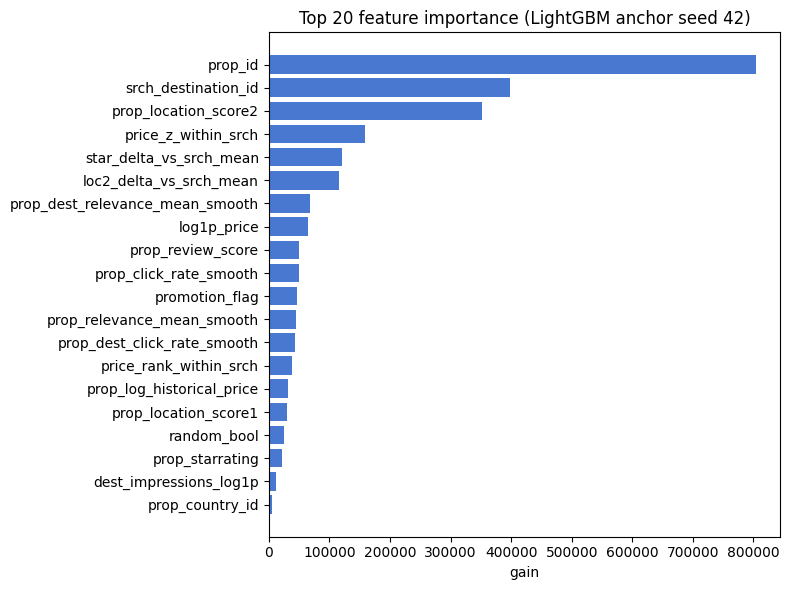

In [13]:
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "gain": anchor_model.booster_.feature_importance(importance_type="gain"),
    "splits": anchor_model.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)
top20 = importance.head(20)
print(top20.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20["feature"][::-1], top20["gain"][::-1], color="#4878d0")
ax.set_xlabel("gain")
ax.set_title("Top 20 feature importance (LightGBM anchor seed 42)")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_top20.png", dpi=110)
plt.show()

## Save models and metadata

Saving each seed model so notebook 06 can either re-use them or re-train with `n_estimators` set to the val-best iteration. I am also storing the best_iter per seed because that is what the final full-train fit needs.

In [14]:
for seed, model in seed_models.items():
    model_path = MODELS_DIR / f"lgbm_seed{seed}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"saved {model_path.name} ({model_path.stat().st_size / 1e6:.1f} MB)")

xgb_path = MODELS_DIR / "xgb_rank.pkl"
with open(xgb_path, "wb") as f:
    pickle.dump(xgb_model, f)
print(f"saved {xgb_path.name} ({xgb_path.stat().st_size / 1e6:.1f} MB)")

best_iters_path = PROC_DIR / "seed_best_iters.json"
with open(best_iters_path, "w") as f:
    json.dump({str(k): int(v) for k, v in seed_best_iters.items()}, f)
print(f"saved {best_iters_path.name}")

xgb_meta_path = PROC_DIR / "xgb_meta.json"
with open(xgb_meta_path, "w") as f:
    json.dump({"best_iter": int(xgb_model.best_iteration), "chosen_w_xgb_blend": float(CHOSEN_W_XGB)}, f)
print(f"saved {xgb_meta_path.name}")

saved lgbm_seed42.pkl (39.3 MB)


saved lgbm_seed123.pkl (38.3 MB)


saved lgbm_seed456.pkl (34.4 MB)
saved xgb_rank.pkl (8.1 MB)
saved seed_best_iters.json
saved xgb_meta.json


## Summary table

Everything I learned in one place.

In [15]:
summary = pd.DataFrame([
    {"experiment": "anchor (seed 42)", "val_ndcg5": anchor_ndcg, "best_iter": anchor_best_iter},
    *[{"experiment": f"sweep: {r['override']}", "val_ndcg5": r["val_ndcg5"], "best_iter": np.nan} for r in sweep_runs],
    {"experiment": "xgb_rank", "val_ndcg5": xgb_ndcg, "best_iter": xgb_model.best_iteration},
    {"experiment": "bias-corrected (random x2)", "val_ndcg5": bias_ndcg, "best_iter": np.nan},
    *[{"experiment": f"lgbm seed {s}", "val_ndcg5": seed_ndcgs[s], "best_iter": seed_best_iters[s]} for s in SEEDS if s != 42],
    {"experiment": "3-seed average ensemble", "val_ndcg5": ensemble_ndcg, "best_iter": np.nan},
    {"experiment": f"final blend (w_xgb={CHOSEN_W_XGB})", "val_ndcg5": final_blend_results[CHOSEN_W_XGB], "best_iter": np.nan},
])
print(summary.to_string(index=False))
summary.to_csv(PROC_DIR / "modelling_results.csv", index=False)
print()
print("modelling results saved to data/processed/modelling_results.csv")

                  experiment  val_ndcg5  best_iter
            anchor (seed 42)   0.402763      325.0
        sweep: num_leaves=15   0.403272        NaN
        sweep: num_leaves=63   0.401688        NaN
   sweep: learning_rate=0.03   0.402769        NaN
sweep: min_child_samples=100   0.402956        NaN
                    xgb_rank   0.406597      531.0
  bias-corrected (random x2)   0.398586        NaN
               lgbm seed 123   0.401110      309.0
               lgbm seed 456   0.402419      283.0
     3-seed average ensemble   0.403103        NaN
     final blend (w_xgb=0.6)   0.409898        NaN

modelling results saved to data/processed/modelling_results.csv


In [16]:
del train
gc.collect()
print(f"final RSS: {rss_gb():.2f} GB")

final RSS: 5.19 GB
